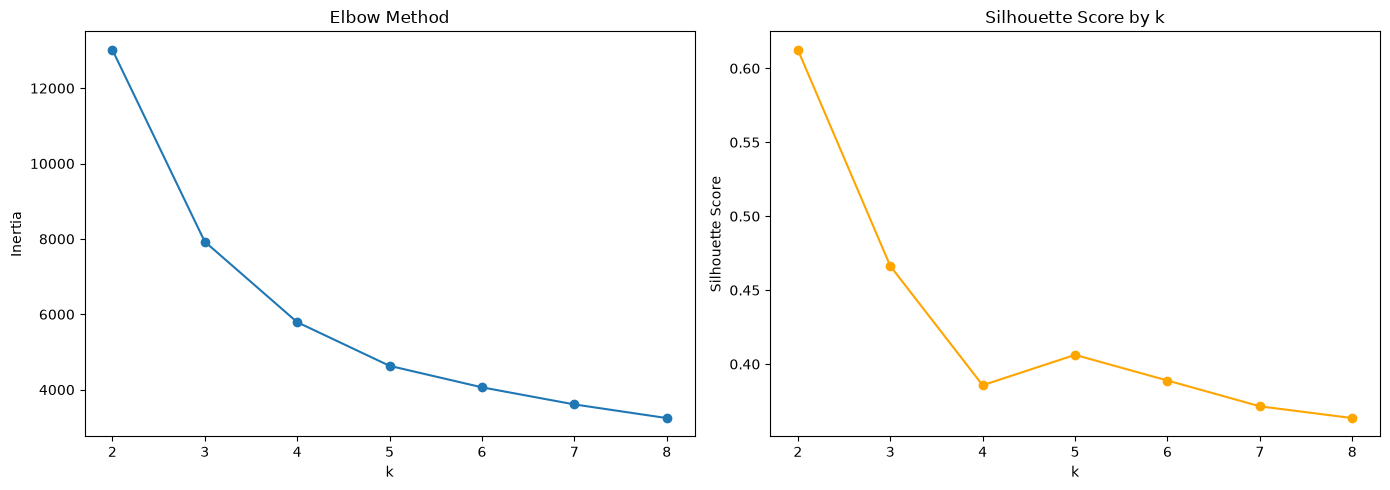

In [2]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("../data/processed/synthetic_viewing_behavior.csv")

features = ['obs_avg_sessions_per_week', 'avg_completion_rate', 'obs_days_since_last_watch', 'genre_diversity', 'tenure_days']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

### Choosing k

The elbow method shows a gradually flattening curve without a single sharp 
bend, making it ambiguous on its own (k=4, 5, or 6 are all plausible by eye). 
The silhouette score resolves this: it peaks distinctly at k=5 (0.416), 
outperforming both k=4 (0.376) and k=6 (0.398). We proceed with k=5.

In [3]:
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby('cluster')[features].mean().round(2)
cluster_profile['size'] = df['cluster'].value_counts().sort_index()
print(cluster_profile)

print()
print(pd.crosstab(df['cluster'], df['persona']))

         obs_avg_sessions_per_week  avg_completion_rate  \
cluster                                                   
0                             6.84                 0.64   
1                             0.00                 0.00   
2                            20.00                 0.85   
3                             3.91                 0.30   
4                             6.86                 0.64   

         obs_days_since_last_watch  genre_diversity  tenure_days  size  
cluster                                                                 
0                             0.66             5.93       564.04  1243  
1                            60.00            11.43        15.01   493  
2                             0.06             6.46       448.97  1025  
3                             7.17             5.55       291.64   983  
4                             0.69             5.90       247.87  1256  

persona  casual_viewer  churning_user  new_user  power_binger  weekend_wat

### Cluster Interpretation vs Ground-Truth Personas 

With the corrected observation window features, Power Bingers and Churning 
Users remain perfectly separated (100% purity each). New Users now form 
their own clean cluster (n=493) rather than a small edge case because 
the cold-start fix means every new user has identical zero-history 
features within the 60-day observation window, making them trivially 
distinguishable from established users. Casual Viewers and Weekend 
Watchers still merge into two overlapping clusters, consistent with the 
earlier finding that these personas differ mainly in genre/timing 
preferences not captured in the clustering features.

In [4]:
cluster_names = {
    2: 'Power Bingers',
    3: 'Churning Users',
    0: 'Steady Regulars',      
    4: 'Steady Regulars',      
    1: 'New / Cold-Start Users',
}
df['segment'] = df['cluster'].map(cluster_names)

In [5]:
df.to_csv("../data/processed/user_segments.csv", index=False)